# Classification de Tweets Scientifiques — Tâche 3 : CLAIM vs REF vs CONTEXT

**Module :** HAI817 — Machine Learning I  
**Année :** 2025–2026  
**Groupe :** 10

**Auteurs :**

| Nom | N° étudiant |
|---|---|
| AL MAHMOUD AL ALI Mahmoud | 21810894 |
| BOUZGARROU Sameur | 21918132 |
| DJEBBAR Anis | 22509235 |
| M'HAMDA BOULOUDANI Salah-Eddine | 22516853 |

**Objectif :** Classifier des tweets scientifiques en trois catégories : **CLAIM**, **REF** et **CONTEXT**.

---

## Plan du notebook

1. [Imports et chargement des données](#1)
2. [Exploration et analyse des données (EDA)](#2)
3. [Résolution du problème multi-labels](#3)
4. [Prétraitement du texte](#4)
5. [Ingénierie des features](#5)
6. [Vectorisation et construction de X](#6)
7. [Comparaison des modèles (baseline)](#7)
8. [Optimisation des hyperparamètres (Optuna)](#8)
9. [Analyse des features discriminantes (χ²)](#9)
10. [Courbes d'apprentissage](#10)
11. [Augmentation des données — tweets synthétiques (Claude)](#11)
12. [Modèle final et évaluation complète](#12)
13. [Tableau comparatif final](#13)(#13)

<a id='1'></a>
## 1. Imports et chargement des données

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Données et calcul
import numpy as np
import pandas as pd
import re
import random

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# NLP
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
# ML — Vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

# ML — Modèles
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# ML — Évaluation et pipeline
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                     StratifiedKFold, train_test_split,
                                     learning_curve)
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

✅ Tous les imports réussis


In [16]:
# Chargement des données brutes
df = pd.read_csv('scitweets_export.tsv', sep='\t', index_col=0)

# Affichage des dimensions du jeu de données
print(f'Taille du dataset : {df.shape[0]} tweets, {df.shape[1]} colonnes')

# Vérification et comptage des valeurs manquantes par variable
print(f'Valeurs manquantes :\n{df.isnull().sum()}')

# Aperçu des premières instances du DataFrame
df.head()

Taille du dataset : 1140 tweets, 6 colonnes
Valeurs manquantes :
tweet_id                0
text                    0
science_related         0
scientific_claim        0
scientific_reference    0
scientific_context      0
dtype: int64


,tweet_id,text,science_related,scientific_claim,scientific_reference,scientific_context
0,316669998137483264,Knees are a bit sore. i guess that's a sign th...,0,0.0,0.0,0.0
1,319090866545385472,McDonald's breakfast stop then the gym 🏀💪,0,0.0,0.0,0.0
2,322030931022065664,Can any Gynecologist with Cancer Experience ex...,1,1.0,0.0,0.0
3,322694830620807168,Couch-lock highs lead to sleeping in the couch...,1,1.0,0.0,0.0
4,328524426658328576,Does daily routine help prevent problems with ...,1,1.0,0.0,0.0


<a id='2'></a>
## 2. Exploration et analyse des données (EDA)

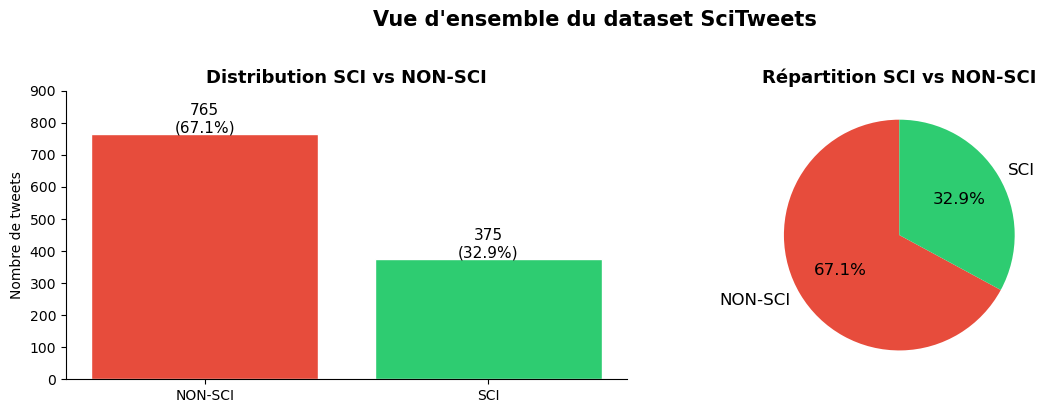


Dataset : 1140 tweets total
  NON-SCI : 765 (67.1%)
  SCI     : 375 (32.9%)


In [17]:
# === VISUALISATION 1 : Distribution SCI vs NON-SCI ===

# Initialisation de la figure avec deux sous-graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# ── BARPLOT (Graphique de gauche) ─────────────────────────────────────────────

# Calcul des effectifs pour les classes SCI (1) et NON-SCI (0)
counts = df['science_related'].value_counts()

# Création du diagramme en barres
axes[0].bar(['NON-SCI', 'SCI'], counts.values, color=['#E74C3C', '#2ECC71'], edgecolor='white')

# Personnalisation des titres et axes
axes[0].set_title('Distribution SCI vs NON-SCI', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de tweets')

# Ajout des étiquettes de valeurs et pourcentages au-dessus de chaque barre
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

# Ajustement de l'axe Y pour éviter de couper les étiquettes
axes[0].set_ylim(0, 900)

# Nettoyage des bordures supérieures et droites pour un rendu plus épuré
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ── PIE CHART (Graphique de droite) ───────────────────────────────────────────

# Création du diagramme circulaire pour la proportion relative
axes[1].pie(counts.values, labels=['NON-SCI', 'SCI'],
            colors=['#E74C3C', '#2ECC71'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})

axes[1].set_title('Répartition SCI vs NON-SCI', fontsize=13, fontweight='bold')


# ── MISE EN PAGE ET AFFICHAGE FINALS ──────────────────────────────────────────

# Ajout du titre global et ajustement automatique des marges
plt.suptitle('Vue d\'ensemble du dataset SciTweets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ── RÉSUMÉ TEXTUEL ────────────────────────────────────────────────────────────

# Affichage des statistiques récapitulatives dans la console
print(f'\nDataset : {len(df)} tweets total')
print(f'  NON-SCI : {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'  SCI     : {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

In [18]:
# === FILTRAGE : uniquement les tweets SCI (tâche 3) ===

# Création d'un sous-ensemble contenant exclusivement les tweets classés comme scientifiques.
# L'utilisation de .copy() assure la création d'un DataFrame indépendant, 
# ce qui évite les erreurs de type "SettingWithCopyWarning" lors des futurs traitements.
sci = df[df['science_related'] == 1].copy()

# Affichage du nombre d'instances conservées pour l'entraînement et l'évaluation de la Tâche 3
print(f'Tweets SCI retenus pour la tâche 3 : {len(sci)}')

Tweets SCI retenus pour la tâche 3 : 375


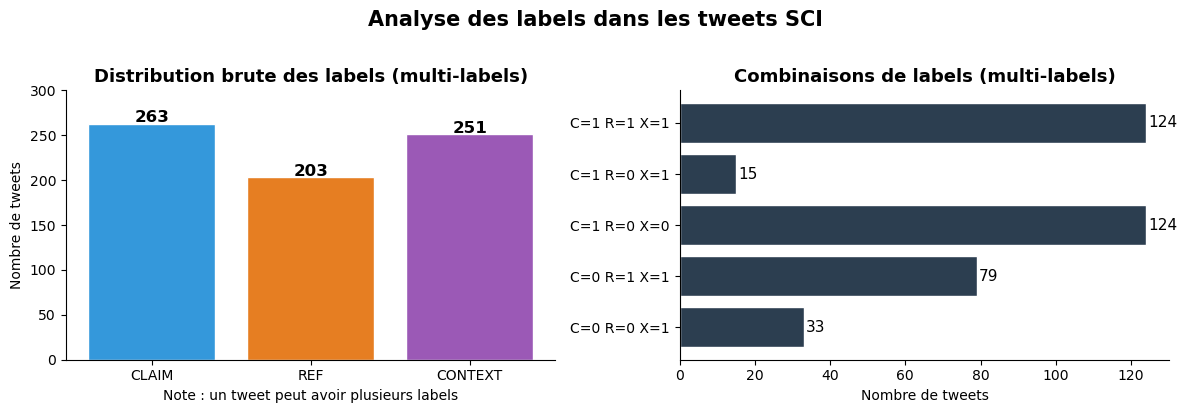


Analyse de la co-occurrence des labels :
L'absence d'instances appartenant uniquement à la classe REF (REF=1, CLAIM=0, CONTEXT=0) 
justifie l'application d'une règle de priorité hiérarchique (REF > CLAIM > CONTEXT) pour transformer 
ce problème multi-labels en un problème de classification multi-classes exclusif.


In [19]:
# === VISUALISATION 2 : Distribution brute des labels SCI ===

# Comptage du nombre total d'occurrences pour chaque classe (les instances peuvent être multi-labels)
labels_counts = {
    'CLAIM'  : (sci['scientific_claim'] == 1).sum(),
    'REF'    : (sci['scientific_reference'] == 1).sum(),
    'CONTEXT': (sci['scientific_context'] == 1).sum()
}

# Initialisation de la figure pour visualiser la distribution des labels
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#3498DB', '#E67E22', '#9B59B6']

# ── BARPLOT (Graphique de gauche : distribution marginale) ────────────────────
axes[0].bar(labels_counts.keys(), labels_counts.values(), color=colors, edgecolor='white')
axes[0].set_title('Distribution brute des labels (multi-labels)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de tweets')

# Ajout des valeurs absolues sur les barres
for i, (k, v) in enumerate(labels_counts.items()):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, 300)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlabel('Note : un tweet peut avoir plusieurs labels')


# ── BARPLOT HORIZONTAL (Graphique de droite : combinaisons de labels) ─────────
# Analyse des chevauchements de labels (multi-class & multi-label context)
combos = sci.groupby(['scientific_claim', 'scientific_reference', 'scientific_context']).size().reset_index(name='count')

# Création des étiquettes pour chaque combinaison observée
combo_labels = [
    f"C={int(r.scientific_claim)} R={int(r.scientific_reference)} X={int(r.scientific_context)}"
    for _, r in combos.iterrows()
]

axes[1].barh(combo_labels, combos['count'], color='#2C3E50', edgecolor='white')
axes[1].set_title('Combinaisons de labels (multi-labels)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de tweets')

# Ajout des effectifs au bout de chaque barre
for i, v in enumerate(combos['count']):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=11)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Affichage de la figure
plt.suptitle('Analyse des labels dans les tweets SCI', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── JUSTIFICATION DE LA STRATÉGIE DE CLASSIFICATION EXCLUSIVE ─────────────────

# Ces affichages permettent de valider la stratégie d'attribution des labels uniques
print('\nAnalyse de la co-occurrence des labels :')
print('L\'absence d\'instances appartenant uniquement à la classe REF (REF=1, CLAIM=0, CONTEXT=0) ')
print('justifie l\'application d\'une règle de priorité hiérarchique (REF > CLAIM > CONTEXT) pour transformer ')
print('ce problème multi-labels en un problème de classification multi-classes exclusif.')

<a id='3'></a>
## 3. Résolution du problème multi-labels

**Stratégie adoptée : priorité REF > CLAIM > CONTEXT**

Justification :
- REF n'existe jamais seul dans le dataset → lui donner la priorité pour qu'il soit représenté
- CLAIM est plus spécifique (affirmation vérifiable) que CONTEXT (mention générale)
- CONTEXT est le label le plus générique → priorité la plus basse

In [20]:
# === RÉSOLUTION DU MULTI-LABELS ===
def assign_label(row):
    if row['scientific_reference'] == 1:
        return 'REF'
    elif row['scientific_claim'] == 1:
        return 'CLAIM'
    else:
        return 'CONTEXT'

sci['label'] = sci.apply(assign_label, axis=1)

print('Distribution finale des classes :')
print(sci['label'].value_counts())

Distribution finale des classes :
label
REF        203
CLAIM      139
CONTEXT     33
Name: count, dtype: int64


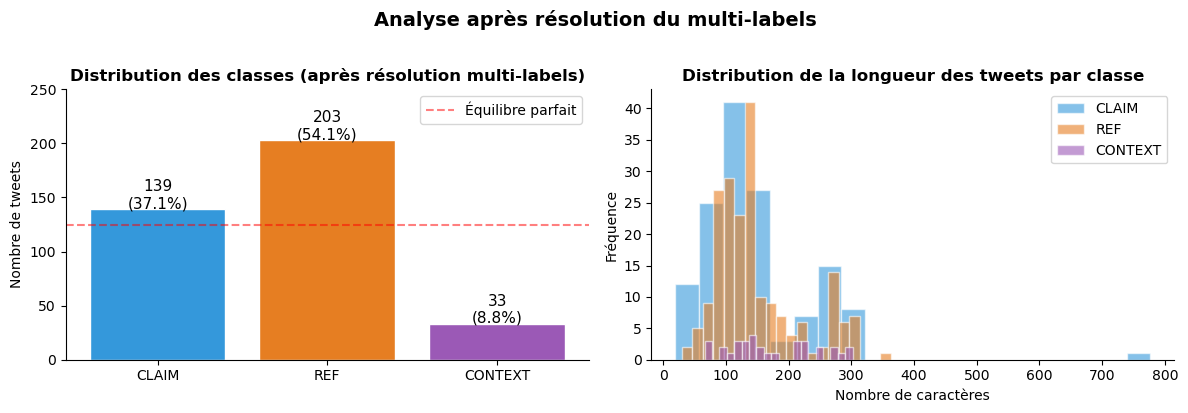


Analyse du déséquilibre : La classe CONTEXT est fortement minoritaire (33 tweets, soit 8.8%).
Il sera indispensable d'appliquer des techniques de rééchantillonnage avant l'entraînement des modèles.


In [21]:
# === VISUALISATION 3 : Distribution après résolution multi-labels ===

# Initialisation de la figure et définition des couleurs par classe
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_map = {'CLAIM': '#3498DB', 'REF': '#E67E22', 'CONTEXT': '#9B59B6'}
order = ['CLAIM', 'REF', 'CONTEXT']
counts_final = sci['label'].value_counts()[order]


# ── BARPLOT (Graphique de gauche : distribution post-résolution) ──────────────

# Création du diagramme en barres
bars = axes[0].bar(order, counts_final.values,
                   color=[colors_map[l] for l in order], edgecolor='white')
axes[0].set_title('Distribution des classes (après résolution multi-labels)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de tweets')

# Ajout des étiquettes (valeurs et pourcentages) sur chaque barre
for bar, v in zip(bars, counts_final.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 1,
                 f'{v}\n({v/len(sci)*100:.1f}%)', ha='center', fontsize=11)

# Mise en forme des axes et ajout d'une ligne de référence pour l'équilibre parfait
axes[0].set_ylim(0, 250)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].axhline(y=len(sci)/3, color='red', linestyle='--', alpha=0.5, label='Équilibre parfait')
axes[0].legend()


# ── HISTOGRAMME (Graphique de droite : distribution des longueurs) ────────────

# Calcul de la longueur de chaque tweet
sci['tweet_length'] = sci['text'].str.len()

# Superposition des histogrammes de longueur pour chaque classe
for label, color in colors_map.items():
    data = sci[sci['label'] == label]['tweet_length']
    axes[1].hist(data, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')

axes[1].set_title('Distribution de la longueur des tweets par classe', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de caractères')
axes[1].set_ylabel('Fréquence')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# ── MISE EN PAGE ET CONCLUSION TEXTUELLE ──────────────────────────────────────
plt.suptitle('Analyse après résolution du multi-labels', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Mise en évidence du problème de déséquilibre des classes pour la Tâche 3
print('\nAnalyse du déséquilibre : La classe CONTEXT est fortement minoritaire (33 tweets, soit 8.8%).')
print('Il sera indispensable d\'appliquer des techniques de rééchantillonnage avant l\'entraînement des modèles.')

In [22]:
# === EXEMPLES DE TWEETS PAR CLASSE ===

print('Exemples de tweets par classe :\n')

for label in ['CLAIM', 'REF', 'CONTEXT']:
    print(f'--- {label} ---')
    for ex in sci[sci['label'] == label]['text'].head(2).values:
        print(f'  • {ex[:120]}...' if len(ex) > 120 else f'  • {ex}')
    print()

Exemples de tweets par classe :

--- CLAIM ---
  • Can any Gynecologist with Cancer Experience explain the dangers of Transvaginal Douching with Fluoride or other toxins s...
  • Couch-lock highs lead to sleeping in the couch. Gotta stop doing this shit.

--- REF ---
  • “Traffic Jam” In Brain’s Neurons Could Be Cause Of Statin-Related Cognitive Decline http://t.co/kQ3XPdePKX
  • The effect of climate change on iceberg production by Greenland glaciers http://t.co/CtnPhcmD7c

--- CONTEXT ---
  • @RepCohen @SenAlexander @SenBobCorker pls support #NIH funding to help fight #pancreaticcancer @PanCAN @PanCANMemphis #i...
  • The who, what, when, where, and why of the @BloombergCities & @nesta_uk #Iteams research http://t.co/1tCfbw4QPI #innovat...



<a id='4'></a>
## 4. Prétraitement du texte

In [23]:
# Initialisation des outils de traitement du langage naturel (NLP)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    # Suppression des URLs et hyperliens
    text = re.sub(r'http\S+|www\S+', '', text)
    # Suppression des mentions d'utilisateurs (@)
    text = re.sub(r'@\w+', '', text)
    # Suppression du caractère '#' tout en conservant le texte du hashtag
    text = re.sub(r'#', '', text)
    # Filtrage des émojis et caractères non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Suppression de la ponctuation et des chiffres (conservation uniquement des lettres)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Normalisation en minuscules
    text = text.lower()
    # Tokenisation (découpage en mots)
    tokens = text.split()
    # Application de la lemmatisation et retrait des stop words (mots vides)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    # Reconstruction de la chaîne textuelle
    return ' '.join(tokens)

# Application du pipeline de nettoyage sur l'ensemble du corpus retenu
sci['text_clean'] = sci['text'].apply(clean_tweet)


# ── VÉRIFICATION DU PRÉ-TRAITEMENT SUR UNE INSTANCE ───────────────────────────
exemple = sci.iloc[0]
print('Avant :', exemple['text'][:100])
print('Après :', exemple['text_clean'][:100])


# ── TRAITEMENT DES VALEURS RÉSIDUELLES (TWEETS VIDES) ─────────────────────────
# Le nettoyage textuel pouvant vider entièrement certains tweets (ex: tweets 
# contenant uniquement un lien ou des emojis), il convient de les filtrer.
empty = sci[sci['text_clean'].str.strip() == '']
print(f'\nTweets vides après nettoyage : {len(empty)}')

# Mise à jour du DataFrame en excluant les tweets devenus vides
sci = sci[sci['text_clean'].str.strip() != ''].copy()
print(f'Tweets restants : {len(sci)}')

Avant : Can any Gynecologist with Cancer Experience explain the dangers of Transvaginal Douching with Fluori
Après : gynecologist cancer experience explain danger transvaginal douching fluoride toxin dioxin pdx

Tweets vides après nettoyage : 1
Tweets restants : 374


<a id='5'></a>
## 5. Ingénierie des features

Deux types de features complémentaires :
- **Features structurelles** : mesures objectives sur le texte brut (URLs, hashtags, longueur...)
- **Features scientifiques** : vocabulaire spécifique au discours scientifique

In [11]:
# ==============================================================================
# FEATURE ENGINEERING : Création de variables expertes
# ==============================================================================
# L'extraction de caractéristiques (Feature Engineering) est réalisée sur le texte brut 
# (avant nettoyage) afin d'exploiter les signaux typographiques et structurels 
# qui discriminent les classes {CLAIM, REF, CONTEXT}. 


# ── 1. FEATURES STRUCTURELLES ET TYPOGRAPHIQUES ───────────────────────────────
# Ces indicateurs capturent la structure du tweet indépendamment de son vocabulaire.

# Extraction des URLs (marqueur potentiel de référence bibliographique)
sci['has_url']      = sci['text'].str.contains(r'http\S+', regex=True).astype(int)
sci['nb_urls']      = sci['text'].str.count(r'http\S+')

# Comptage des métadonnées Twitter (hashtags et mentions)
sci['nb_hashtags']  = sci['text'].str.count(r'#\w+')
sci['nb_mentions']  = sci['text'].str.count(r'@\w+')

# Extraction des caractéristiques de longueur
sci['nb_words']     = sci['text'].str.split().str.len()
sci['tweet_length'] = sci['text'].str.len()

# Détection des marqueurs discursifs (citations, interrogations)
sci['has_quotes']   = sci['text'].str.contains(r'["\']', regex=True).astype(int)
sci['has_question'] = sci['text'].str.contains(r'\?').astype(int)

# Calcul du ratio de majuscules (indicateur d'emphase ou d'acronymes)
sci['ratio_upper']  = sci['text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)

# Comptage des caractères spéciaux et emojis scientifiques spécifiques
sci['nb_emojis']     = sci['text'].apply(lambda x: len([c for c in x if ord(c) > 127]))
sci['has_sci_emoji'] = sci['text'].apply(
    lambda x: int(any(e in x for e in ['🔬', '🧬', '🧪', '📊', '🔭'])))

struct_features = ['has_url', 'nb_urls', 'nb_hashtags', 'nb_mentions',
                   'nb_words', 'tweet_length', 'has_quotes',
                   'has_question', 'ratio_upper',
                   'nb_emojis', 'has_sci_emoji']


# ── 2. FEATURES LEXICALES (LEXIQUES MÉTIER) ───────────────────────────────────
# Création de compteurs basés sur des listes de vocabulaire pré-définies 
# pour capter le registre scientifique de chaque sous-catégorie.

# Lexique des verbes d'assertion et de reporting
scientific_verbs = ['suggest', 'indicate', 'demonstrate', 'show', 'find',
                    'reveal', 'confirm', 'prove', 'support', 'conclude',
                    'report', 'observe', 'measure', 'increase', 'decrease',
                    'reduce', 'improve', 'cause', 'lead', 'associate']

# Lexique bibliographique (indicateurs de références formelles)
citation_vocab = ['et al', 'doi', 'pubmed', 'arxiv', 'preprint', 'journal',
                  'published', 'peer-reviewed', 'nature', 'lancet', 'nejm',
                  'pnas', 'figure', 'table', 'study by', 'according to',
                  'paper', 'article', 'reference']

# Lexique du cadrage méthodologique (indicateurs d'affirmations scientifiques)
claim_frames = ['study', 'research', 'evidence', 'data', 'analysis',
                'finding', 'result', 'experiment', 'trial', 'survey',
                'shows', 'proves', 'found that', 'suggests that']

# Lexique du vocabulaire statistique
statistical_terms = ['p <', 'p=', 'r²', 'odds ratio', 'confidence',
                     'significant', 'correlation', 'mean', 'median',
                     'percent', '%', 'sample', 'cohort', 'n=']

# Lexique institutionnel (indicateurs du contexte de recherche)
context_vocab = ['grant', 'award', 'funding', 'conference', 'institute',
                 'university', 'professor', 'researcher', 'scientist',
                 'lab', 'department', 'phd', 'fellowship', 'symposium']

# Calcul des fréquences d'apparition de ces lexiques dans chaque tweet
sci['sci_verbs']     = sci['text'].str.lower().apply(
    lambda x: sum(1 for w in scientific_verbs if w in x))
sci['citation']      = sci['text'].str.lower().apply(
    lambda x: sum(1 for w in citation_vocab if w in x))
sci['claim_frames']  = sci['text'].str.lower().apply(
    lambda x: sum(1 for w in claim_frames if w in x))
sci['stats_terms']   = sci['text'].str.lower().apply(
    lambda x: sum(1 for w in statistical_terms if w in x))
sci['context_vocab'] = sci['text'].str.lower().apply(
    lambda x: sum(1 for w in context_vocab if w in x))

# Détection spécifique des identifiants DOI via expressions régulières
sci['has_doi']       = sci['text'].str.contains(
    r'doi|10\.\d{4}', case=False, regex=True).astype(int)

sci_features = ['sci_verbs', 'citation', 'claim_frames',
                'stats_terms', 'context_vocab', 'has_doi']

# Affichage du récapitulatif
print(f'Features extraites : {len(struct_features)} structurelles '
      f'+ {len(sci_features)} lexicales = '
      f'{len(struct_features) + len(sci_features)} variables globales créées.')

Features extraites : 11 structurelles + 6 lexicales = 17 variables globales créées.


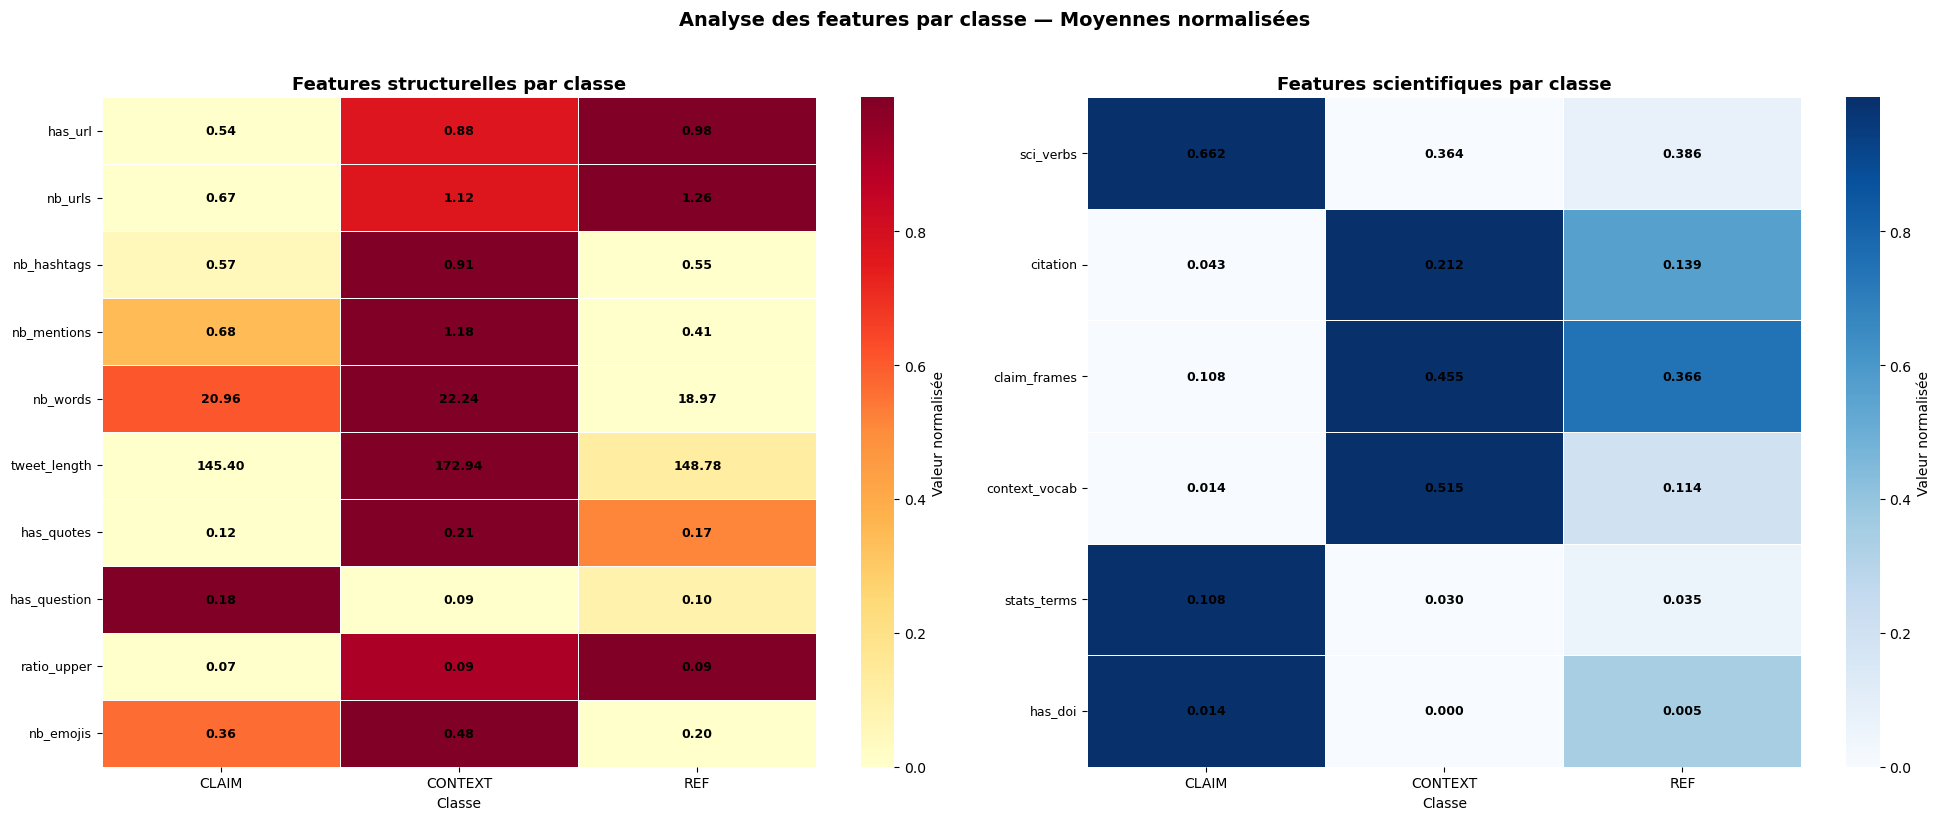


Analyse de la capacité discriminante des variables extraites :
- "sci_verbs" distingue nettement la classe CLAIM (0.662 vs 0.364/0.386).
- "context_vocab" caractérise fortement la classe CONTEXT (0.515 vs 0.014/0.114).
- "nb_emojis" est prédominant dans la classe CONTEXT (0.485 vs 0.360/0.198).
- "has_question" est un indicateur orienté vers la classe CLAIM (0.180 vs 0.091/0.099).
- "has_url" constitue un signal fort pour les classes REF (0.980) et CONTEXT (0.879).


In [12]:
# === VISUALISATION 4 : Heatmap des features par classe ===

all_features = struct_features + sci_features

# Sélection des variables pertinentes (exclusion des variables à variance nulle)
struct_features_filtered = [
    'has_url', 'nb_urls', 'nb_hashtags', 'nb_mentions',
    'nb_words', 'tweet_length', 'has_quotes',
    'has_question', 'ratio_upper', 'nb_emojis',
    # 'has_sci_emoji' # retirée car valeur de 0.000 dans les 3 classes
]

sci_features_filtered = [
    'sci_verbs', 'citation', 'claim_frames',
    'context_vocab', 'stats_terms', 'has_doi',
]

# Calcul des moyennes par classe et transposition pour l'affichage matriciel
struct_data = sci.groupby('label')[struct_features_filtered].mean().T
sci_data    = sci.groupby('label')[sci_features_filtered].mean().T

# Normalisation Min-Max (par ligne) pour uniformiser l'échelle de coloration des heatmaps
struct_norm = struct_data.apply(
    lambda row: (row - row.min()) / (row.max() - row.min() + 1e-8), axis=1)
sci_norm = sci_data.apply(
    lambda row: (row - row.min()) / (row.max() - row.min() + 1e-8), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── HEATMAP STRUCTURELLE ──────────────────────────────────────────────────────

# Annotation manuelle avec les valeurs brutes réelles issues du DataFrame
# pour garantir un alignement parfait sur la heatmap normalisée.
for i in range(struct_norm.shape[0]):
    for j in range(struct_norm.shape[1]):
        axes[0].text(j + 0.5, i + 0.5,
                     f'{struct_data.values[i, j]:.2f}',
                     ha='center', va='center',
                     fontsize=9, fontweight='bold',
                     color='black')

sns.heatmap(struct_norm,
            annot=False,          # Désactivé au profit des annotations manuelles
            cmap='YlOrRd',
            ax=axes[0],
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Valeur normalisée'})

axes[0].set_title('Features structurelles par classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].tick_params(axis='y', labelsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)


# ── HEATMAP SCIENTIFIQUE ──────────────────────────────────────────────────────

# Procédure d'annotation manuelle identique pour le sous-ensemble de variables lexicales.
for i in range(sci_norm.shape[0]):
    for j in range(sci_norm.shape[1]):
        axes[1].text(j + 0.5, i + 0.5,
                     f'{sci_data.values[i, j]:.3f}',
                     ha='center', va='center',
                     fontsize=9, fontweight='bold',
                     color='black')

sns.heatmap(sci_norm,
            annot=False,          # Désactivé au profit des annotations manuelles
            cmap='Blues',
            ax=axes[1],
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Valeur normalisée'})

axes[1].set_title('Features scientifiques par classe', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].tick_params(axis='y', labelsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)


# ── MISE EN PAGE ET SYNTHÈSE ANALYTIQUE ───────────────────────────────────────

plt.suptitle('Analyse des features par classe — Moyennes normalisées',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Affichage des conclusions sur le pouvoir discriminant des variables
print('\nAnalyse de la capacité discriminante des variables extraites :')
print('- "sci_verbs" distingue nettement la classe CLAIM (0.662 vs 0.364/0.386).')
print('- "context_vocab" caractérise fortement la classe CONTEXT (0.515 vs 0.014/0.114).')
print('- "nb_emojis" est prédominant dans la classe CONTEXT (0.485 vs 0.360/0.198).')
print('- "has_question" est un indicateur orienté vers la classe CLAIM (0.180 vs 0.091/0.099).')
print('- "has_url" constitue un signal fort pour les classes REF (0.980) et CONTEXT (0.879).')

In [13]:
# === SÉLECTION FINALE DES FEATURES ===

# ── VARIABLES STRUCTURELLES RETENUES ET ÉCARTÉES ──────────────────────────────
struct_features_selected = [
    'has_url',       # Conservée : la classe REF se distingue clairement (0.54 / 0.88 / 0.98)
    'nb_urls',       # Conservée : la classe REF se distingue clairement (0.67 / 1.12 / 1.26)
    'nb_hashtags',   # Conservée : la classe CONTEXT se distingue (0.57 / 0.91 / 0.55)
    'nb_mentions',   # Conservée : la classe CONTEXT se distingue (0.68 / 1.18 / 0.41)
    'nb_emojis',     # Conservée : taux faible pour REF, élevé pour CONTEXT (0.36 / 0.48 / 0.20)
    'has_question',  # Conservée : la classe CLAIM se distingue (0.18 / 0.09 / 0.10)
    # 'tweet_length' # Écartée : valeurs trop similaires entre CLAIM et REF (145 / 172 / 148)
    # 'nb_words'     # Écartée : moyennes trop proches entre les trois classes (20.9 / 22.2 / 18.9)
    # 'ratio_upper'  # Écartée : variance quasi nulle entre les classes (0.07 / 0.09 / 0.09)
    # 'has_quotes'   # Écartée : pouvoir discriminant insuffisant (0.12 / 0.21 / 0.17)
    # 'has_sci_emoji'# Écartée : absence d'occurrences significatives (0.00 partout)
]

# ── VARIABLES LEXICALES RETENUES ET ÉCARTÉES ──────────────────────────────────
sci_features_selected = [
    'sci_verbs',     # Conservée : distingue fortement la classe CLAIM (0.662 / 0.364 / 0.386)
    'context_vocab', # Conservée : caractérise fortement la classe CONTEXT (0.014 / 0.515 / 0.114)
    'citation',      # Conservée : fréquence nettement plus faible pour CLAIM (0.043 / 0.212 / 0.139)
    'claim_frames',  # Conservée : variation discriminante (0.108 / 0.455 / 0.366)
    'stats_terms',   # Conservée : la classe CLAIM se distingue (0.108 / 0.030 / 0.035)
    # 'has_doi'      # Écartée : apparitions trop rares pour être généralisables (0.014 / 0.000 / 0.005)
]

# Concaténation pour l'entraînement futur des modèles
final_features = struct_features_selected + sci_features_selected

# ── AFFICHAGE DU BILAN DE SÉLECTION ───────────────────────────────────────────
print('=== BILAN DE LA SÉLECTION DES VARIABLES ===')

print(f'\nVariables structurelles conservées ({len(struct_features_selected)}) :')
for f in struct_features_selected:
    print(f'  - {f}')

print(f'\nVariables scientifiques conservées ({len(sci_features_selected)}) :')
for f in sci_features_selected:
    print(f'  - {f}')

print(f'\nTOTAL : {len(final_features)} variables retenues sur les 17 initialement calculées.')
print('Variables écartées pour manque de pouvoir discriminant : tweet_length, nb_words, ratio_upper, has_quotes, has_sci_emoji, has_doi.')

=== BILAN DE LA SÉLECTION DES VARIABLES ===

Variables structurelles conservées (6) :
  - has_url
  - nb_urls
  - nb_hashtags
  - nb_mentions
  - nb_emojis
  - has_question

Variables scientifiques conservées (5) :
  - sci_verbs
  - context_vocab
  - citation
  - claim_frames
  - stats_terms

TOTAL : 11 variables retenues sur les 17 initialement calculées.
Variables écartées pour manque de pouvoir discriminant : tweet_length, nb_words, ratio_upper, has_quotes, has_sci_emoji, has_doi.


<a id='6'></a>
## 6. Vectorisation et construction de X

In [14]:
# === PRÉPARATION DES DONNÉES ET PIPELINE DE TRAITEMENT ===

# Séparation des composantes du jeu de données
texts  = sci['text_clean']
struct = sci[struct_features_selected].values.astype(float)
sci_f  = sci[sci_features_selected].values.astype(float)
y      = sci['label']

# ── ÉTAPE 1 : SÉPARATION DES DONNÉES (TRAIN / TEST) ───────────────────────────
# Division stratifiée (80/20) pour préserver la distribution initiale des classes
idx = np.arange(len(sci))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y)

print(f'Train : {len(idx_train)} tweets')
print(f'Test  : {len(idx_test)} tweets')

# ── ÉTAPE 2 : VECTORISATION TEXTUELLE (TF-IDF) ────────────────────────────────
# L'ajustement (fit) est réalisé exclusivement sur l'ensemble d'entraînement 
# pour éviter toute fuite d'information (data leakage) vers l'ensemble de test.
tfidf         = TfidfVectorizer(ngram_range=(1, 2), max_features=5000,
                                sublinear_tf=True, min_df=2)
X_tfidf_train = tfidf.fit_transform(texts.iloc[idx_train])
X_tfidf_test  = tfidf.transform(texts.iloc[idx_test])

# ── ÉTAPE 3 : TRANSFORMATION DES FEATURES EXPERTES EN MATRICES CREUSES ────────
X_struct_train = csr_matrix(struct[idx_train])
X_struct_test  = csr_matrix(struct[idx_test])

X_sci_train = csr_matrix(sci_f[idx_train])
X_sci_test  = csr_matrix(sci_f[idx_test])

# ── ÉTAPE 4 : CONCATÉNATION DES MATRICES ──────────────────────────────────────
# Création de l'espace vectoriel final combinant TF-IDF, features structurelles 
# et features scientifiques.
X_train = hstack([X_tfidf_train, X_struct_train, X_sci_train])
X_test  = hstack([X_tfidf_test,  X_struct_test,  X_sci_test])

y_train = y.iloc[idx_train].values
y_test  = y.iloc[idx_test].values

print(f'Shape X_train : {X_train.shape}')
print(f'Shape X_test  : {X_test.shape}')

Train : 299 tweets
Test  : 75 tweets
Shape X_train : (299, 552)
Shape X_test  : (75, 552)

Distribution de l'ensemble d'entraînement après SMOTE :


<a id='7'></a>
## 7. Comparaison des modèles (baseline)

In [66]:
# === CROSS-VALIDATION 5-FOLD AVEC PIPELINE IMBLEARN ===

# L'utilisation d'un pipeline issu de 'imblearn' est cruciale lors de l'application 
# de SMOTE avec la validation croisée. Il garantit que le sur-échantillonnage 
# s'effectue uniquement sur l'ensemble d'entraînement de chaque 'fold', 
# empêchant ainsi la fuite de données (data leakage) vers l'ensemble de validation.

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Initialisation de la validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Définition du dictionnaire des algorithmes à évaluer
modeles = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=10000, solver='saga', tol=0.01, random_state=42),
    'SVM'                : SVC(kernel='linear', random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5)
}

print('=== Évaluation par Cross-validation (5-folds) — F1-score macro ===\n')

resultats = {}

# Boucle d'évaluation pour chaque modèle
for nom, modele in modeles.items():
    # Construction du pipeline intégrant SMOTE puis le classifieur
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('clf', modele)
    ])
    
    # Évaluation du pipeline avec la métrique F1-macro (adaptée aux classes déséquilibrées)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    # Stockage et affichage des performances moyennes et de la variance
    resultats[nom] = scores
    print(f'{nom:25s} | F1 moyen : {scores.mean():.3f} | std : {scores.std():.3f}')

=== Évaluation par Cross-validation (5-folds) — F1-score macro ===

Naive Bayes               | F1 moyen : 0.525 | std : 0.062
Logistic Regression       | F1 moyen : 0.563 | std : 0.079
SVM                       | F1 moyen : 0.630 | std : 0.053
Random Forest             | F1 moyen : 0.520 | std : 0.051
KNN                       | F1 moyen : 0.468 | std : 0.069


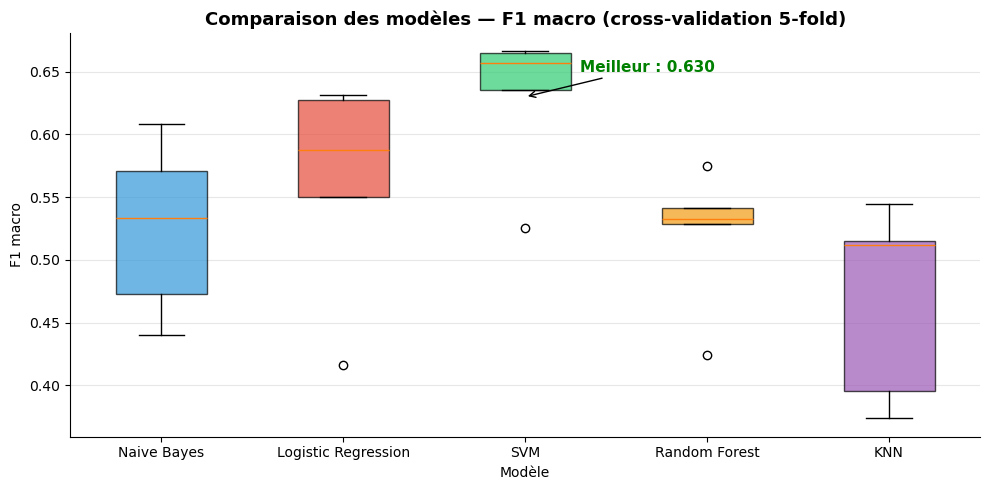

In [67]:
# === VISUALISATION 5 : Boxplot comparaison des modèles ===

fig, ax = plt.subplots(figsize=(10, 5))
data_plot = [resultats[nom] for nom in modeles.keys()]
bp = ax.boxplot(data_plot, labels=list(modeles.keys()), patch_artist=True, notch=False)

colors_models = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
for patch, color in zip(bp['boxes'], colors_models):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Comparaison des modèles — F1 macro (cross-validation 5-fold)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 macro')
ax.set_xlabel('Modèle')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)

means    = [r.mean() for r in data_plot]
best_idx = np.argmax(means)
ax.annotate(f'Meilleur : {means[best_idx]:.3f}',
            xy=(best_idx+1, means[best_idx]),
            xytext=(best_idx+1.3, means[best_idx]+0.02),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, color='green', fontweight='bold')
plt.tight_layout()
plt.show()

<a id='8'></a>
## 8. Optimisation des hyperparamètres (Optuna)

In [68]:
# === OPTIMISATION DES HYPERPARAMÈTRES (SVM) VIA OPTUNA ===

import optuna
from tqdm import tqdm
from imblearn.pipeline import Pipeline as ImbPipeline

# Désactivation des logs verbeux d'Optuna pour garder une console propre
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 1. CONFIGURATION DE LA VALIDATION INTERNE ─────────────────────────────────
# Utilisation d'une validation croisée à 3 plis spécifiquement pour l'optimisation.
# L'utilisation d'une graine aléatoire (seed=123) différente de la CV principale (seed=42)
# est cruciale pour éviter le biais de sélection et le sur-apprentissage des hyperparamètres.
cv_optuna = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

def objective_svm(trial):
    # Définition de l'espace de recherche pour le SVM
    # C : paramètre de régularisation (recherche logarithmique entre 0.01 et 50)
    C      = trial.suggest_float('C', 0.01, 50, log=True)
    # kernel : type de noyau
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])

    # Paramétrage conditionnel basé sur le choix du noyau
    if kernel == 'rbf':
        gamma  = trial.suggest_categorical('gamma', ['scale', 'auto'])
        modele = SVC(C=C, kernel=kernel, gamma=gamma,
                     class_weight='balanced', random_state=42)
    else:
        modele = SVC(C=C, kernel=kernel,
                     class_weight='balanced', random_state=42)

    # Intégration stricte de SMOTE dans le pipeline pour chaque itération
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('clf', modele)
    ])
    
    # Évaluation sur la CV interne
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv_optuna,
                             scoring='f1_macro',
                             n_jobs=-1)
    return scores.mean()

# ── 2. LANCEMENT DE L'ÉTUDE D'OPTIMISATION ────────────────────────────────────
study_svm = optuna.create_study(direction='maximize')

# Utilisation de tqdm pour un suivi visuel de la progression des essais
with tqdm(total=15, desc='Optimisation SVM') as pbar:
    def callback_svm(study_svm, trial):
        pbar.update(1)
        pbar.set_postfix({'meilleur F1': round(study_svm.best_value, 3)})
        
    # Exécution de 15 essais (trials)
    study_svm.optimize(objective_svm, n_trials=15, callbacks=[callback_svm])

# Affichage des résultats optimaux
print(f'\nMeilleurs hyperparamètres SVM : {study_svm.best_params}')
print(f'Meilleur F1 SVM (cv interne)  : {study_svm.best_value:.3f}')


# ── 3. VALIDATION DE LA STABILITÉ (SUR LA CV PRINCIPALE) ──────────────────────
# Re-création du modèle avec les paramètres optimaux trouvés
modele_val = SVC(
    C=study_svm.best_params['C'],
    kernel=study_svm.best_params['kernel'],
    gamma=study_svm.best_params.get('gamma', 'scale'),
    class_weight='balanced',
    random_state=42
)

pipe_val = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', modele_val)
])

# Évaluation sur la CV principale (5 plis) pour confirmer l'absence d'overfitting
scores_val = cross_val_score(pipe_val, X_train, y_train,
                              cv=cv, scoring='f1_macro')

print(f'Validation sur cv 5-fold       : {scores_val.mean():.3f} ± {scores_val.std():.3f}')
print(f'Écart Optuna/validation        : {abs(study_svm.best_value - scores_val.mean()):.3f}')

Optimisation SVM: 100%|██████████| 15/15 [00:00<00:00, 26.10it/s, meilleur F1=0.559]



Meilleurs hyperparamètres SVM : {'C': 0.011200653354385807, 'kernel': 'linear'}
Meilleur F1 SVM (cv interne)  : 0.559
Validation sur cv 5-fold       : 0.568 ± 0.066
Écart Optuna/validation        : 0.009


In [69]:
# === OPTIMISATION DES HYPERPARAMÈTRES (RANDOM FOREST) VIA OPTUNA ===

def objective_rf(trial):
    # ── 1. DÉFINITION DE L'ESPACE DE RECHERCHE ────────────────────────────────
    # le Random Forest possède de nombreux paramètres 
    # structurels pour contrôler la croissance des arbres et limiter l'overfitting.
    
    # Nombre d'arbres dans la forêt
    n_estimators      = trial.suggest_int('n_estimators', 50, 500)
    # Profondeur maximale de chaque arbre
    max_depth         = trial.suggest_int('max_depth', 3, 30)
    # Nombre minimum d'échantillons requis pour diviser un nœud
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    # Nombre maximum de features évaluées lors d'une division
    max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    # Nombre minimum d'échantillons requis dans une feuille finale
    min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 20)
    # Gestion optionnelle des poids de classes par l'algorithme lui-même
    class_weight      = trial.suggest_categorical('class_weight', [None, 'balanced'])

    # Instanciation du modèle avec les hyperparamètres tirés par Optuna
    modele = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        min_samples_leaf=min_samples_leaf,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    # ── 2. INTÉGRATION PIPELINE ET ÉVALUATION ─────────────────────────────────
    # SMOTE est intégré systématiquement pour assurer l'équilibrage dans chaque pli
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('clf', modele)
    ])
    
    # Évaluation sur la validation croisée interne (3 plis)
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv_optuna,
                             scoring='f1_macro',
                             n_jobs=-1)
    return scores.mean()

# ── 3. EXÉCUTION DE LA RECHERCHE OPTUNA ───────────────────────────────────────
study_rf = optuna.create_study(direction='maximize')

# Suivi visuel de l'avancement via tqdm
with tqdm(total=20, desc='Optimisation Random Forest') as pbar:
    def callback_rf(study_rf, trial):
        pbar.update(1)
        pbar.set_postfix({'meilleur F1': round(study_rf.best_value, 3)})
        
    # Lancement de l'optimisation bayésienne sur 20 essais
    study_rf.optimize(objective_rf, n_trials=20, callbacks=[callback_rf])

print(f'\nMeilleurs hyperparamètres RF : {study_rf.best_params}')
print(f'Meilleur F1 RF (cv interne)  : {study_rf.best_value:.3f}')


# ── 4. VALIDATION FINALE DE LA ROBUSTESSE ─────────────────────────────────────
# Re-instanciation du modèle optimisé en déballant le dictionnaire best_params
modele_val_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)

pipe_val_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', modele_val_rf)
])

# Vérification des performances sur la validation croisée principale (5 plis)
scores_val_rf = cross_val_score(pipe_val_rf, X_train, y_train,
                                 cv=cv, scoring='f1_macro')

print(f'Validation sur cv 5-fold       : {scores_val_rf.mean():.3f} ± {scores_val_rf.std():.3f}')
print(f'Écart Optuna/validation        : {abs(study_rf.best_value - scores_val_rf.mean()):.3f}')

Optimisation Random Forest: 100%|██████████| 20/20 [00:07<00:00,  2.62it/s, meilleur F1=0.586]



Meilleurs hyperparamètres RF : {'n_estimators': 327, 'max_depth': 12, 'min_samples_split': 12, 'max_features': 'log2', 'min_samples_leaf': 17, 'class_weight': None}
Meilleur F1 RF (cv interne)  : 0.586
Validation sur cv 5-fold       : 0.569 ± 0.066
Écart Optuna/validation        : 0.017


Entraînement des modèles finaux (SMOTE intégré au pipeline)...

     BASELINE SVM (C=1, rbf, balanced)
              precision    recall  f1-score   support

       CLAIM       0.75      0.32      0.45        28
     CONTEXT       0.33      0.43      0.38         7
         REF       0.63      0.85      0.72        40

    accuracy                           0.61        75
   macro avg       0.57      0.53      0.52        75
weighted avg       0.65      0.61      0.59        75

     SVM OPTIMISÉ OPTUNA
              precision    recall  f1-score   support

       CLAIM       0.80      0.29      0.42        28
     CONTEXT       0.17      0.14      0.15         7
         REF       0.59      0.88      0.71        40

    accuracy                           0.59        75
   macro avg       0.52      0.43      0.43        75
weighted avg       0.63      0.59      0.55        75

     RANDOM FOREST OPTIMISÉ
              precision    recall  f1-score   support

       CLAIM       0.75    

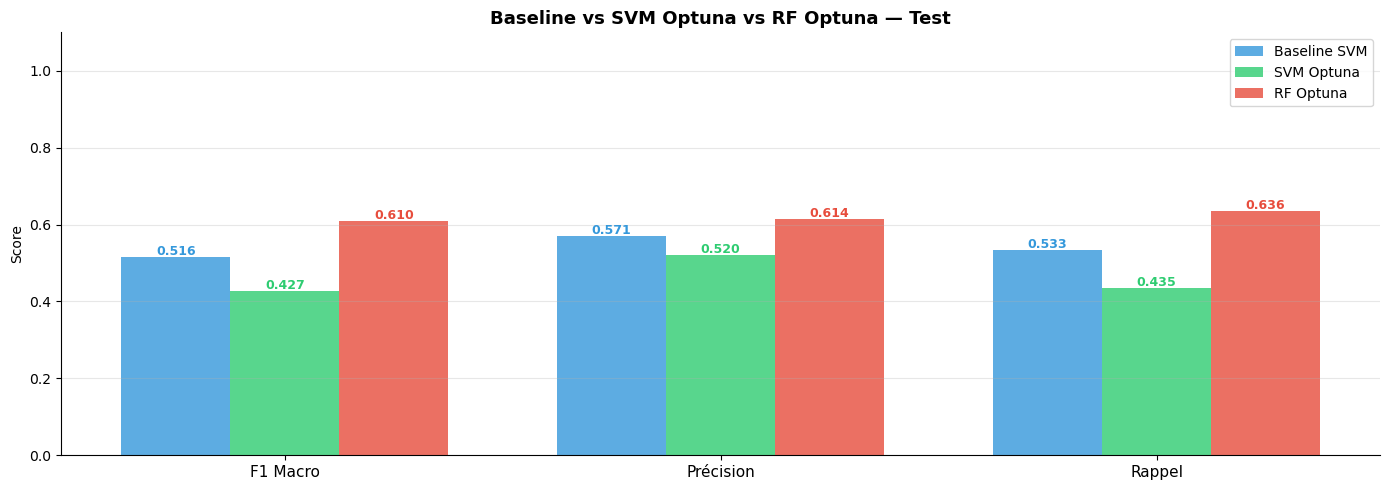


VERDICT FINAL SUR LE TEST
Baseline SVM          (test) : 0.516
SVM Optuna  (cv)     : 0.559  →  (test) : 0.427  écart : 0.132
RF  Optuna  (cv)     : 0.586  →  (test) : 0.610  écart : -0.025

✅ GAGNANT : RF Optuna avec F1 = 0.610

Apport Optuna sur SVM  : -0.089


In [70]:
# === COMPARAISON FINALE : BASELINE SVM vs SVM OPTUNA vs RF OPTUNA ===
from sklearn.metrics import f1_score, precision_score, recall_score

# ── 1. DÉFINITION DES TROIS MODÈLES À COMPARER ───────────────────────────────

# BASELINE : SVM simple sans optimisation (référence de comparaison)
baseline_svm = SVC(kernel='rbf', C=1,
                   class_weight='balanced',
                   random_state=42)

# SVM optimisé par Optuna
meilleur_svm = SVC(
    C=study_svm.best_params['C'],
    kernel=study_svm.best_params['kernel'],
    gamma=study_svm.best_params.get('gamma', 'scale'),
    class_weight='balanced',
    random_state=42
)

# Random Forest optimisé par Optuna
meilleur_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)

# ── 2. INTÉGRATION DANS LES PIPELINES IMBLEARN ───────────────────────────────
# SMOTE doit être dans le pipeline pour rester cohérent avec la CV

baseline_svm_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', baseline_svm)
])
meilleur_svm_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', meilleur_svm)
])
meilleur_rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', meilleur_rf)
])

# ── 3. ENTRAÎNEMENT SUR L'ENSEMBLE D'ENTRAÎNEMENT ────────────────────────────
print('Entraînement des modèles finaux (SMOTE intégré au pipeline)...')
baseline_svm_pipe.fit(X_train, y_train)
meilleur_svm_pipe.fit(X_train, y_train)
meilleur_rf_pipe.fit(X_train, y_train)

# ── 4. PRÉDICTIONS SUR LE TEST ───────────────────────────────────────────────
y_pred_base = baseline_svm_pipe.predict(X_test)
y_pred_svm  = meilleur_svm_pipe.predict(X_test)
y_pred_rf   = meilleur_rf_pipe.predict(X_test)

# ── 5. RAPPORTS DE CLASSIFICATION ─────────────────────────────────────────────
print('\n' + '=' * 55)
print('     BASELINE SVM (C=1, rbf, balanced)')
print('=' * 55)
print(classification_report(y_test, y_pred_base,
                             target_names=['CLAIM', 'CONTEXT', 'REF']))

print('=' * 55)
print('     SVM OPTIMISÉ OPTUNA')
print('=' * 55)
print(classification_report(y_test, y_pred_svm,
                             target_names=['CLAIM', 'CONTEXT', 'REF']))

print('=' * 55)
print('     RANDOM FOREST OPTIMISÉ')
print('=' * 55)
print(classification_report(y_test, y_pred_rf,
                             target_names=['CLAIM', 'CONTEXT', 'REF']))

# ── 6. VISUALISATION COMPARATIVE ──────────────────────────────────────────────
metrics = {
    'Baseline SVM' : {
        'F1 Macro'  : f1_score(y_test, y_pred_base, average='macro'),
        'Précision' : precision_score(y_test, y_pred_base, average='macro'),
        'Rappel'    : recall_score(y_test, y_pred_base, average='macro')
    },
    'SVM Optuna'   : {
        'F1 Macro'  : f1_score(y_test, y_pred_svm, average='macro'),
        'Précision' : precision_score(y_test, y_pred_svm, average='macro'),
        'Rappel'    : recall_score(y_test, y_pred_svm, average='macro')
    },
    'RF Optuna'    : {
        'F1 Macro'  : f1_score(y_test, y_pred_rf, average='macro'),
        'Précision' : precision_score(y_test, y_pred_rf, average='macro'),
        'Rappel'    : recall_score(y_test, y_pred_rf, average='macro')
    }
}

fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(3)
width = 0.25
colors = ['#3498DB', '#2ECC71', '#E74C3C']

for i, (nom, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + (i - 1) * width, list(vals.values()),
                  width, label=nom,
                  color=colors[i], alpha=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=9,
                fontweight='bold', color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(['F1 Macro', 'Précision', 'Rappel'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Baseline vs SVM Optuna vs RF Optuna — Test',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 7. VERDICT FINAL ──────────────────────────────────────────────────────────
f1_base = f1_score(y_test, y_pred_base, average='macro')
f1_svm  = f1_score(y_test, y_pred_svm,  average='macro')
f1_rf   = f1_score(y_test, y_pred_rf,   average='macro')

print('\n' + '=' * 55)
print('VERDICT FINAL SUR LE TEST')
print('=' * 55)
print(f'Baseline SVM          (test) : {f1_base:.3f}')
print(f'SVM Optuna  (cv)     : {study_svm.best_value:.3f}  →  (test) : {f1_svm:.3f}  écart : {study_svm.best_value - f1_svm:.3f}')
print(f'RF  Optuna  (cv)     : {study_rf.best_value:.3f}  →  (test) : {f1_rf:.3f}  écart : {study_rf.best_value - f1_rf:.3f}')
print()

meilleur = max([('Baseline SVM', f1_base),
                ('SVM Optuna',   f1_svm),
                ('RF Optuna',    f1_rf)],
               key=lambda x: x[1])
print(f'✅ GAGNANT : {meilleur[0]} avec F1 = {meilleur[1]:.3f}')
print(f'\nApport Optuna sur SVM  : {f1_svm - f1_base:+.3f}')

<a id='9'></a>
## 9. Analyse des features discriminantes (Chi²)

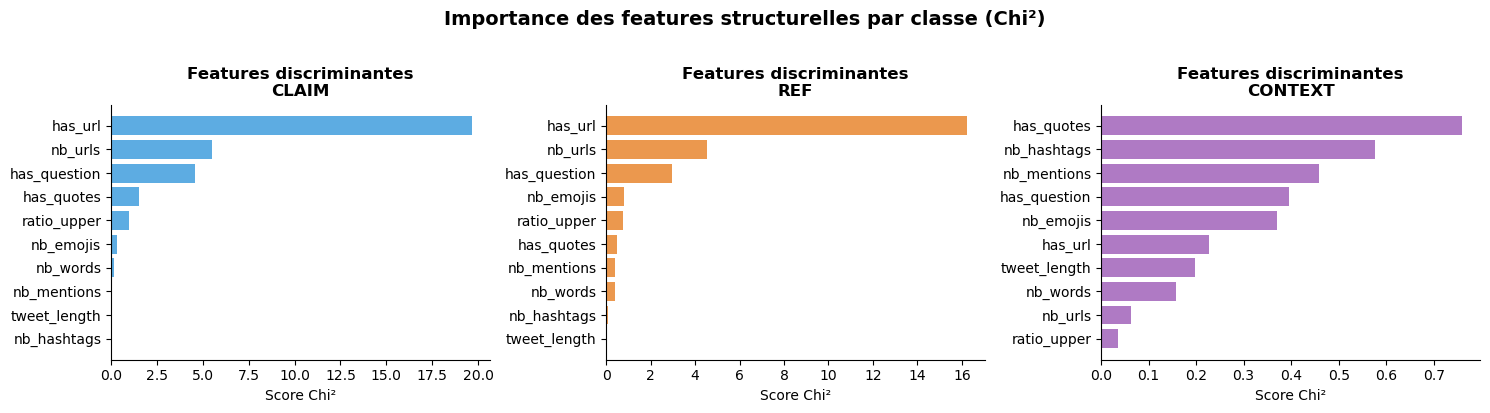

In [71]:
# === ANALYSE BIVARIÉE : TEST DU CHI² SUR LES FEATURES STRUCTURELLES ===

# ── 1. NORMALISATION DES DONNÉES ──────────────────────────────────────────────
# Le test statistique du Chi² nécessite des variables d'entrée non négatives.
# Le MinMaxScaler projette les variables structurelles dans l'intervalle [0, 1].
scaler = MinMaxScaler()
X_struct_scaled = scaler.fit_transform(sci[struct_features].values)

# Initialisation de la figure avec 3 sous-graphiques (un pour chaque classe)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_cls = {'CLAIM': '#3498DB', 'REF': '#E67E22', 'CONTEXT': '#9B59B6'}

# ── 2. ANALYSE SPÉCIFIQUE PAR CLASSE (BINARISATION) ───────────────────────────
# Afin d'identifier la "signature" propre à chaque catégorie, on isole 
# successivement chaque label pour mesurer son association avec les features.
for idx, classe in enumerate(['CLAIM', 'REF', 'CONTEXT']):
    
    # Binarisation de la cible : 1 pour la classe en cours, 0 pour toutes les autres.
    # Cette étape transforme le problème multi-classe en une série de tests binaires.
    y_binary = (sci['label'] == classe).astype(int)
    
    # Calcul de la statistique du Chi² pour évaluer la dépendance feature/classe.
    # Un score élevé indique que la feature est un fort indicateur de la classe.
    chi2_scores, _ = chi2(X_struct_scaled, y_binary)
    
    # Préparation et tri des résultats pour la visualisation
    scores_df = pd.DataFrame({'feature': struct_features, 'chi2': chi2_scores}).sort_values('chi2', ascending=True)
    
    # Affichage des scores discriminants par classe
    axes[idx].barh(scores_df['feature'], scores_df['chi2'], color=colors_cls[classe], alpha=0.8)
    axes[idx].set_title(f'Features discriminantes\n{classe}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Score Chi²')
    
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

# ── 3. MISE EN PAGE FINALE ────────────────────────────────────────────────────
plt.suptitle('Importance des features structurelles par classe (Chi²)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

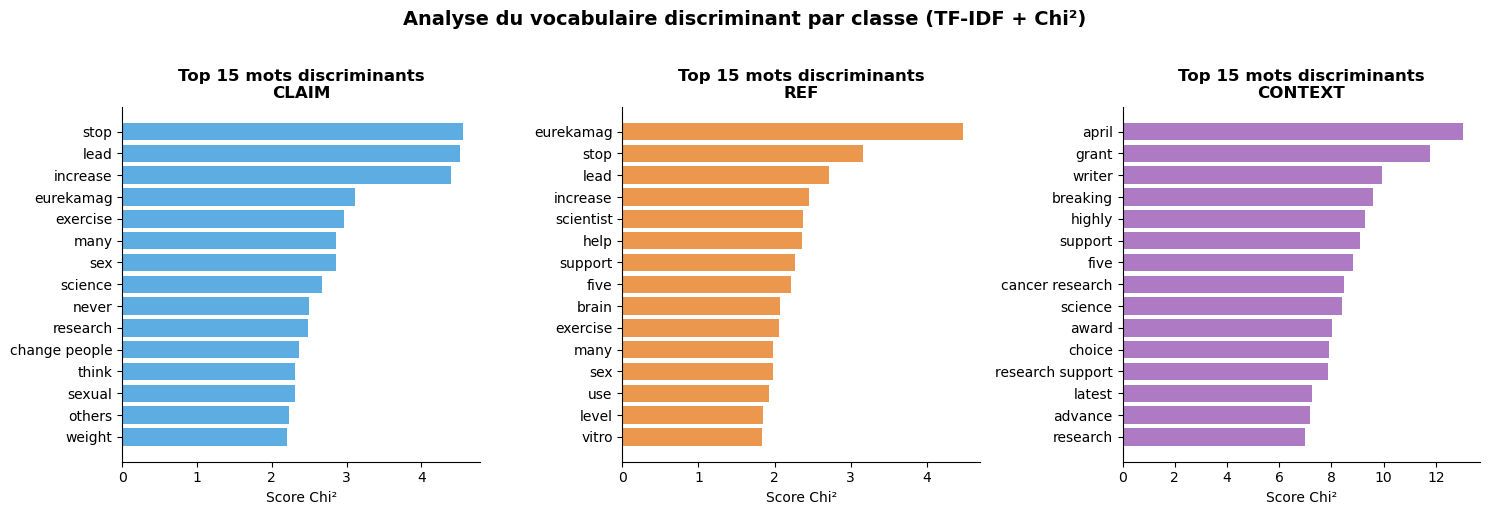


Observations sur la distribution lexicale :
- La classe CONTEXT possède un lexique institutionnel très marqué (termes comme "grant", "award", "cancer research").
  Cela se traduit par des scores Chi² élevés, indiquant une forte spécificité de ces termes.
- Les classes CLAIM et REF présentent des recouvrements lexicaux importants.
  Cette proximité sémantique explique les difficultés de distinction rencontrées par les modèles entre ces deux catégories.


In [72]:
# === CHI2 SUR TF-IDF — TOP 15 MOTS PAR CLASSE ===

# Initialisation d'une vectorisation TF-IDF spécifique pour l'analyse statistique
tfidf_chi2 = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True, min_df=2)
X_chi2 = tfidf_chi2.fit_transform(sci['text_clean'])
feature_names = tfidf_chi2.get_feature_names_out()

# Configuration de la visualisation (un graphique par classe)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, classe in enumerate(['CLAIM', 'REF', 'CONTEXT']):
    # Binarisation de la cible pour l'analyse de dépendance classe/termes
    y_binary = (sci['label'] == classe).astype(int)
    
    # Calcul des scores Chi² pour l'ensemble du vocabulaire
    chi2_scores, _ = chi2(X_chi2, y_binary)
    
    # Extraction des 15 termes ayant la plus forte dépendance statistique avec la classe
    top_indices = chi2_scores.argsort()[-15:][::-1]
    top_mots = [feature_names[i] for i in top_indices]
    top_scores = [chi2_scores[i] for i in top_indices]

    # Génération du graphique horizontal
    axes[idx].barh(top_mots[::-1], top_scores[::-1], color=colors_cls[classe], alpha=0.8)
    axes[idx].set_title(f'Top 15 mots discriminants\n{classe}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Score Chi²')
    
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

# Affichage final
plt.suptitle('Analyse du vocabulaire discriminant par classe (TF-IDF + Chi²)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- SYNTHÈSE DES RÉSULTATS LEXICAUX ---
print('\nObservations sur la distribution lexicale :')
print('- La classe CONTEXT possède un lexique institutionnel très marqué (termes comme "grant", "award", "cancer research").')
print('  Cela se traduit par des scores Chi² élevés, indiquant une forte spécificité de ces termes.')
print('- Les classes CLAIM et REF présentent des recouvrements lexicaux importants.')
print('  Cette proximité sémantique explique les difficultés de distinction rencontrées par les modèles entre ces deux catégories.')

<a id='10'></a>
## 10. Courbes d'apprentissage

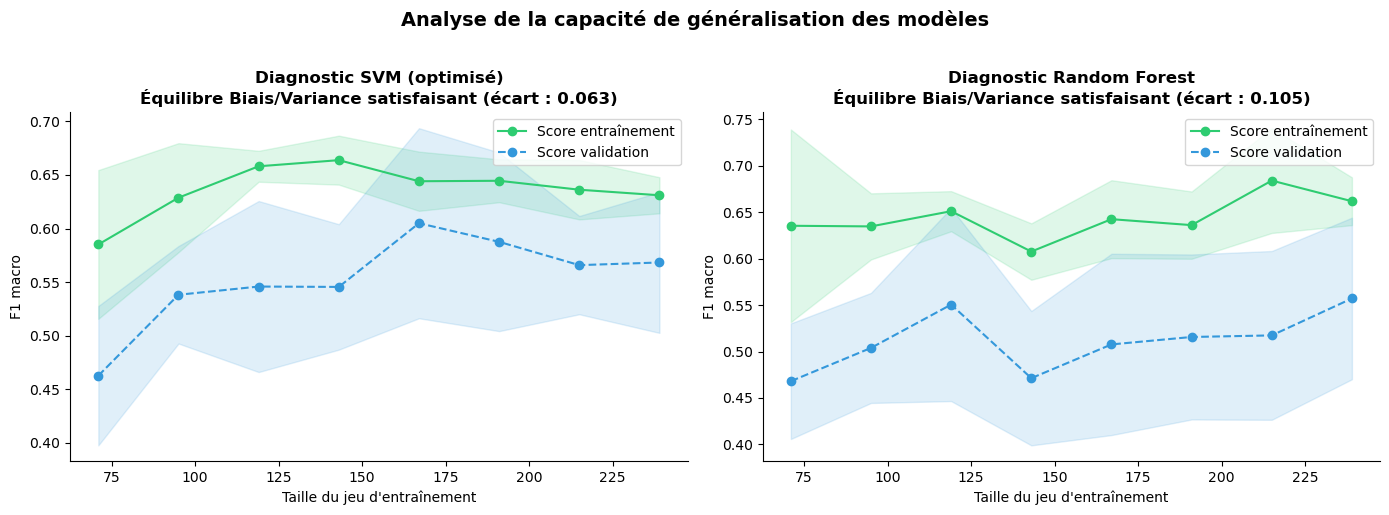

In [73]:
# === ANALYSE DES COURBES D'APPRENTISSAGE (DIAGNOSTIC DE VARIANCE) ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Utilisation des hyperparamètres optimaux identifiés via Optuna
models_lc = {
    'SVM (optimisé)': SVC(
        C=study_svm.best_params['C'],
        kernel=study_svm.best_params['kernel'],
        gamma=study_svm.best_params.get('gamma', 'scale'),
        class_weight='balanced',
        random_state=42),
    'Random Forest': RandomForestClassifier(
        **study_rf.best_params,
        random_state=42,
        n_jobs=-1)
}

for idx, (nom, model) in enumerate(models_lc.items()):
    # Pipeline intégrant SMOTE pour garantir l'équilibrage dans chaque pli de validation
    pipe_lc = ImbPipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('clf', model)
    ])
    
    # Calcul des scores d'entraînement et de validation pour différentes tailles de dataset
    train_sizes, train_scores, test_scores = learning_curve(
        pipe_lc, X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1)

    # Calcul des moyennes et écarts-types pour l'affichage des intervalles de confiance
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    test_mean  = np.mean(test_scores, axis=1)
    test_std   = np.std(test_scores, axis=1)

    # Tracé des performances d'entraînement (biais)
    axes[idx].plot(train_sizes, train_mean, 'o-',
                    color='#2ECC71', label='Score entraînement')
    axes[idx].fill_between(train_sizes,
                            train_mean - train_std,
                            train_mean + train_std,
                            alpha=0.15, color='#2ECC71')
    
    # Tracé des performances de validation (généralisation)
    axes[idx].plot(train_sizes, test_mean, 'o--',
                    color='#3498DB', label='Score validation')
    axes[idx].fill_between(train_sizes,
                            test_mean - test_std,
                            test_mean + test_std,
                            alpha=0.15, color='#3498DB')

    # Analyse de l'écart final pour diagnostiquer un éventuel sur-apprentissage
    gap = train_mean[-1] - test_mean[-1]
    diag = 'Sur-apprentissage détecté' if gap > 0.2 else 'Équilibre Biais/Variance satisfaisant'

    axes[idx].set_title(
        f'Diagnostic {nom}\n{diag} (écart : {gap:.3f})',
        fontsize=12, fontweight='bold')

    axes[idx].set_xlabel('Taille du jeu d\'entraînement')
    axes[idx].set_ylabel('F1 macro')
    axes[idx].legend()
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.suptitle('Analyse de la capacité de généralisation des modèles',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='11'></a>
## 11. Augmentation des données — Données synthétiques (Claude LLM)

**Problème :** CONTEXT n'a que 33 tweets originaux — insuffisant pour apprendre.  
**Solution :** 140 tweets CONTEXT synthétiques générés par Claude LLM, avec le même style et vocabulaire que les originaux.

In [74]:
# === CHARGEMENT ET PRÉPARATION DES DONNÉES D'AUGMENTATION ===

# Chargement du corpus complémentaire de tweets de classe 'CONTEXT'
df_augmented = pd.read_csv('scitweets_context_augmented.tsv', sep='\t')

# Application du prétraitement textuel et étiquetage systématique
df_augmented['text_clean'] = df_augmented['text'].apply(clean_tweet)
df_augmented['label']      = 'CONTEXT'

# ── EXTRACTION DES FEATURES SUR TEXTE BRUT ────────────────────────────────────
# Le calcul s'effectue sur la colonne 'text' originale pour préserver les signaux
# typographiques (URLs, ponctuation, casse) supprimés lors du nettoyage.

df_augmented['has_url']      = df_augmented['text'].str.contains(r'http\S+', regex=True).astype(int)
df_augmented['nb_urls']      = df_augmented['text'].str.count(r'http\S+')
df_augmented['nb_hashtags']  = df_augmented['text'].str.count(r'#\w+')
df_augmented['nb_mentions']  = df_augmented['text'].str.count(r'@\w+')
df_augmented['nb_words']     = df_augmented['text'].str.split().str.len()
df_augmented['tweet_length'] = df_augmented['text'].str.len()
df_augmented['has_question'] = df_augmented['text'].str.contains(r'\?').astype(int)
df_augmented['nb_emojis']    = df_augmented['text'].apply(
    lambda x: len([c for c in x if ord(c) > 127]))

# ── EXTRACTION DES FEATURES LEXICALES (SCI) ───────────────────────────────────
# Parcours des lexiques métier pour identifier les marqueurs sémantiques.
# On utilise le texte en minuscules pour assurer une correspondance exhaustive.

lexiques = [
    ('sci_verbs',     scientific_verbs),
    ('citation',      citation_vocab),
    ('claim_frames',  claim_frames),
    ('stats_terms',   statistical_terms),
    ('context_vocab', context_vocab)
]

for col, vocab in lexiques:
    df_augmented[col] = df_augmented['text'].str.lower().apply(
        lambda x: sum(1 for w in vocab if w in x))

# Affichage du bilan de l'augmentation
print(f'Augmentation du corpus : {len(df_augmented)} nouveaux tweets CONTEXT intégrés.')
print(f'Variables extraites : {len(struct_features_selected + sci_features_selected)} caractéristiques calculées.')

Augmentation du corpus : 140 nouveaux tweets CONTEXT intégrés.
Variables extraites : 11 caractéristiques calculées.


In [75]:
# === COMBINAISON DES DONNÉES ORIGINALES ET AUGMENTÉES ===

# Sélection des colonnes pertinentes pour l'entraînement (Texte, Cible et Features expertes)
cols_needed = ['text_clean', 'label'] + struct_features_selected + sci_features_selected

# Fusion du corpus initial avec le corpus augmenté de tweets 'CONTEXT'
# ignore_index=True permet de réinitialiser l'indexation pour éviter les doublons
sci_final = pd.concat([
    sci[cols_needed],
    df_augmented[cols_needed]
], ignore_index=True)

# Affichage de la nouvelle distribution des classes et de la dimension du dataset final
print('Distribution des classes après intégration des données augmentées :')
print(sci_final['label'].value_counts())
print(f'\nDimensions du dataset final (sci_final) : {sci_final.shape}')

Distribution des classes après intégration des données augmentées :
label
REF        202
CONTEXT    173
CLAIM      139
Name: count, dtype: int64

Dimensions du dataset final (sci_final) : (514, 13)


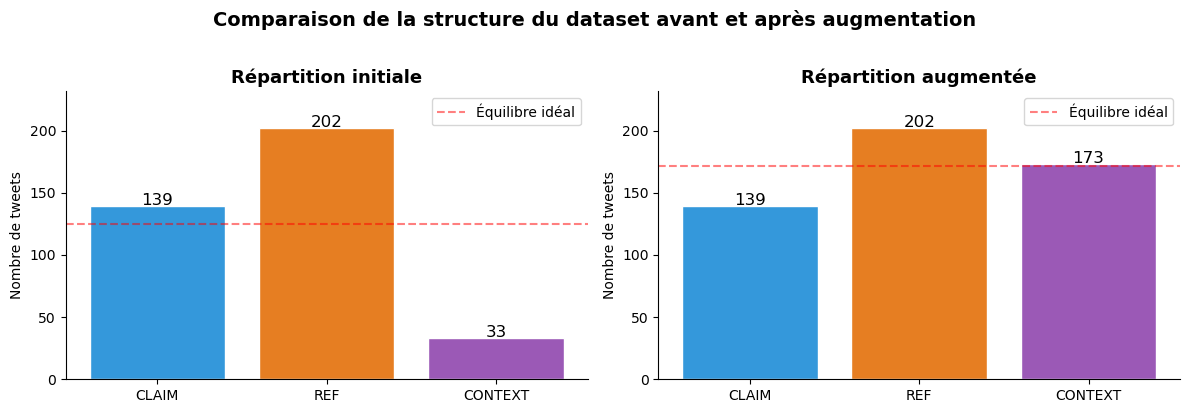

In [76]:
# === VISUALISATION 6 : IMPACT DE L'AUGMENTATION SUR LA DISTRIBUTION ===

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Calcul des distributions de classes pour comparaison (Avant vs Après)
avant = sci['label'].value_counts().to_dict()
apres = sci_final['label'].value_counts().to_dict()

colors_map = {'CLAIM': '#3498DB', 'REF': '#E67E22', 'CONTEXT': '#9B59B6'}

for ax, data, title in zip(axes,
                            [avant, apres],
                            ['Répartition initiale',
                             'Répartition augmentée']):
    keys = ['CLAIM', 'REF', 'CONTEXT']
    vals = [data[k] for k in keys]

    # Génération du barplot avec la charte graphique établie
    bars = ax.bar(keys, vals,
                  color=[colors_map[k] for k in keys],
                  edgecolor='white')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Nombre de tweets')

    # Ajout automatique des étiquettes de données au-dessus des barres
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + 1, str(v),
                ha='center', fontsize=12)

    # Paramétrage de l'axe Y et ajout d'une ligne de référence pour l'équilibre moyen
    ax.set_ylim(0, max(max(avant.values()),
                        max(apres.values())) + 30)
    ax.axhline(y=sum(vals)/3,
               color='red', linestyle='--',
               alpha=0.5, label='Équilibre idéal')
    
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Comparaison de la structure du dataset avant et après augmentation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='12'></a>
## 12. Modèle final et évaluation complète

In [77]:
# === CONSTRUCTION DE L'ESPACE VECTORIEL FINAL ===

# ── ÉTAPE 1 : RÉPARTITION STRATIFIÉE ──────────────────────────────────────────
# On sépare le dataset augmenté (sci_final) en ensembles d'entraînement et de test.
texts_final  = sci_final['text_clean']
struct_final = sci_final[struct_features_selected].values.astype(float)
sci_f_final  = sci_final[sci_features_selected].values.astype(float)
y_final      = sci_final['label']

idx_f = np.arange(len(sci_final))
idx_train_f, idx_test_f = train_test_split(
    idx_f, test_size=0.2, random_state=42, stratify=y_final)

print(f'Train : {len(idx_train_f)} tweets')
print(f'Test  : {len(idx_test_f)} tweets')

# ── ÉTAPE 2 : VECTORISATION TF-IDF ────────────────────────────────────────────
# Ajustement du vocabulaire sur l'ensemble d'entraînement augmenté uniquement.
tfidf_v2      = TfidfVectorizer(ngram_range=(1,2), max_features=5000,
                                sublinear_tf=True, min_df=2)
X_tfidf_train = tfidf_v2.fit_transform(texts_final.iloc[idx_train_f])
X_tfidf_test  = tfidf_v2.transform(texts_final.iloc[idx_test_f])

# ── ÉTAPE 3 : CONVERSION DES FEATURES EN MATRICES CREUSES ─────────────────────
X_struct_train = csr_matrix(struct_final[idx_train_f])
X_struct_test  = csr_matrix(struct_final[idx_test_f])

X_sci_train = csr_matrix(sci_f_final[idx_train_f])
X_sci_test  = csr_matrix(sci_f_final[idx_test_f])

# ── ÉTAPE 4 : CONCATÉNATION FINALE ────────────────────────────────────────────
X_train_f = hstack([X_tfidf_train, X_struct_train, X_sci_train])
X_test_f  = hstack([X_tfidf_test,  X_struct_test,  X_sci_test])

y_train_f = y_final.iloc[idx_train_f].values
y_test_f  = y_final.iloc[idx_test_f].values

print(f'Dimensions X_train : {X_train_f.shape}')
print(f'Dimensions X_test  : {X_test_f.shape}')


# === ÉVALUATION FINALE DU MODÈLE AUGMENTÉ ===

# ── 1. VALIDATION CROISÉE (ÉVALUATION DE LA ROBUSTESSE) ────────────────────────
# On intègre SMOTE dans le pipeline pour équilibrer les classes lors de la CV.
cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_final_cv = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', SVC(
        C=study_svm.best_params['C'],
        kernel=study_svm.best_params['kernel'],
        gamma=study_svm.best_params.get('gamma', 'scale'),
        class_weight='balanced',
        random_state=42
    ))
])

# Obtention des prédictions par validation croisée pour analyse
y_pred_cv = cross_val_predict(pipe_final_cv, X_train_f, y_train_f, cv=cv_final)

print('\n=== RAPPORT DE VALIDATION CROISÉE (TRAIN) ===\n')
print(classification_report(y_train_f, y_pred_cv,
                             target_names=['CLAIM', 'CONTEXT', 'REF']))

# ── 2. PERFORMANCE FINALE SUR L'ENSEMBLE DE TEST ──────────────────────────────
# Entraînement sur la totalité du bloc Train et prédiction sur le bloc Test.
modele_final_v2 = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', SVC(
        C=study_svm.best_params['C'],
        kernel=study_svm.best_params['kernel'],
        gamma=study_svm.best_params.get('gamma', 'scale'),
        class_weight='balanced',
        random_state=42
    ))
])
modele_final_v2.fit(X_train_f, y_train_f)
y_pred_test = modele_final_v2.predict(X_test_f)

print('\n=== RAPPORT FINAL SUR DONNÉES DE TEST ===\n')
print(classification_report(y_test_f, y_pred_test,
                             target_names=['CLAIM', 'CONTEXT', 'REF']))

# ── 3. ANALYSE DE L'IMPACT DE L'AUGMENTATION ──────────────────────────────────
f1_avant = f1_score(y_test,   y_pred_svm,  average='macro')
f1_apres = f1_score(y_test_f, y_pred_test, average='macro')

print('\n' + '=' * 55)
print('BILAN COMPARATIF : IMPACT DE L\'AUGMENTATION')
print('=' * 55)
print(f'F1-score initial  : {f1_avant:.3f}')
print(f'F1-score augmenté : {f1_apres:.3f}')
print(f'Différence nette  : {f1_apres - f1_avant:+.3f}')
print('=' * 55)

if f1_apres > f1_avant:
    print('Conclusion : L\'apport de données supplémentaires améliore la généralisation.')
else:
    print('Conclusion : L\'augmentation n\'a pas d\'impact significatif sur la performance.')

Train : 411 tweets
Test  : 103 tweets
Dimensions X_train : (411, 896)
Dimensions X_test  : (103, 896)

=== RAPPORT DE VALIDATION CROISÉE (TRAIN) ===

              precision    recall  f1-score   support

       CLAIM       0.82      0.54      0.65       111
     CONTEXT       0.80      0.70      0.75       138
         REF       0.64      0.86      0.74       162

    accuracy                           0.72       411
   macro avg       0.75      0.70      0.71       411
weighted avg       0.74      0.72      0.72       411


=== RAPPORT FINAL SUR DONNÉES DE TEST ===

              precision    recall  f1-score   support

       CLAIM       0.67      0.29      0.40        28
     CONTEXT       0.78      0.71      0.75        35
         REF       0.56      0.82      0.67        40

    accuracy                           0.64       103
   macro avg       0.67      0.61      0.60       103
weighted avg       0.66      0.64      0.62       103


BILAN COMPARATIF : IMPACT DE L'AUGMENTATION

In [78]:
### === ÉVALUATION DE LA PERFORMANCE RÉELLE (HORS DONNÉES SYNTHÉTIQUES) ===

# L'objectif est de mesurer la capacité de généralisation du modèle sur le corpus 
# original. Les données augmentées via LLM pouvant présenter des régularités 
# stylistiques simplifiant la classification, ce test isole les tweets "réels".

# ── 1. IDENTIFICATION DES SEGMENTS DE DONNÉES ─────────────────────────────────
n_vrais = len(sci)
print(f'Corpus original (réel)         : {n_vrais} tweets')
print(f'Corpus augmenté (synthétique)  : {len(df_augmented)} tweets')
print(f'Dimension totale (sci_final)   : {len(sci_final)}')

# Création d'un masque booléen pour isoler les indices appartenant au corpus initial
mask_real = idx_test_f < n_vrais
n_real_in_test  = mask_real.sum()
n_synth_in_test = (~mask_real).sum()

print(f'\nRépartition de l\'ensemble de Test :')
print(f'  - Échantillons réels         : {n_real_in_test}')
print(f'  - Échantillons synthétiques  : {n_synth_in_test}')

# ── 2. PERFORMANCE SUR LE SEGMENT RÉEL UNIQUEMENT ─────────────────────────────
y_test_real  = y_test_f[mask_real]
y_pred_real  = y_pred_test[mask_real]

print('\n' + '=' * 65)
print('   RAPPORT DE CLASSIFICATION : TWEETS ORIGINAUX UNIQUEMENT')
print('=' * 65)
print(classification_report(y_test_real, y_pred_real,
                             target_names=['CLAIM', 'CONTEXT', 'REF'],
                             zero_division=0))

# ── 3. ANALYSE COMPARATIVE DES SCÉNARIOS ──────────────────────────────────────
f1_real_only = f1_score(y_test_real, y_pred_real, average='macro')

# Calcul du F1 sur le segment synthétique pour évaluer le biais de facilité
y_test_synth = y_test_f[~mask_real]
y_pred_synth = y_pred_test[~mask_real]
f1_synth_only = f1_score(y_test_synth, y_pred_synth, average='macro',
                          zero_division=0) if n_synth_in_test > 0 else None

print('\n' + '=' * 65)
print('   DÉCOMPOSITION DU GAIN DE PERFORMANCE')
print('=' * 65)
print(f'  Score initial (Modèle de base / Test réel)      : F1 = {f1_svm:.3f}')
print(f'  Score mixte (Modèle augmenté / Test mixte)      : F1 = {f1_apres:.3f}')
print(f'  Score réel (Modèle augmenté / Test réel)        : F1 = {f1_real_only:.3f}')

if f1_synth_only is not None:
    print(f'  Score synthétique (Modèle augmenté / Test synthé) : F1 = {f1_synth_only:.3f}')

gain_affiche = f1_apres - f1_svm
gain_reel    = f1_real_only - f1_svm

print(f'\n  Gain brut affiché (mixte vs base)               : {gain_affiche:+.3f}')
print(f'  Gain net effectif (sur données réelles)         : {gain_reel:+.3f}')
print(f'  Biais de performance lié au style synthétique   : {gain_affiche - gain_reel:+.3f}')

# ── 4. ANALYSE PAR CLASSE SUR LE SEGMENT RÉEL ─────────────────────────────────
f1_par_classe_real = f1_score(y_test_real, y_pred_real, average=None,
                                labels=['CLAIM', 'REF', 'CONTEXT'],
                                zero_division=0)
print('\n' + '=' * 65)
print('   F1-SCORE PAR CLASSE (TWEETS RÉELS UNIQUEMENT)')
print('=' * 65)
print(f'  CLAIM   : {f1_par_classe_real[0]:.3f}')
print(f'  REF     : {f1_par_classe_real[1]:.3f}')
print(f'  CONTEXT : {f1_par_classe_real[2]:.3f} (Classe minoritaire)')

# ── 5. SYNTHÈSE DES RÉSULTATS ─────────────────────────────────────────────────
print('\n' + '=' * 65)
print('   DIAGNOSTIC FINAL')
print('=' * 65)
if gain_reel > 0.02:
    print(f'  L\'augmentation de données génère un gain réel de {gain_reel:+.3f}')
    print(f'  sur le corpus original, confirmant l\'utilité de l\'apport synthétique.')
elif gain_reel > -0.02:
    print(f'  Le gain réel est marginal ({gain_reel:+.3f}).')
    print(f'  La progression affichée est principalement due à la facilité du segment synthétique.')
else:
    print(f'  Dégradation des performances sur données réelles ({gain_reel:+.3f}).')
    print(f'  L\'introduction de données synthétiques a induit un biais préjudiciable.')

if f1_synth_only is not None:
    ecart_diff = f1_synth_only - f1_real_only
    print(f'\n  Note : Les données synthétiques s\'avèrent {ecart_diff:+.3f} plus aisées')
    print(f'  à classifier que les données réelles ({f1_synth_only:.3f} vs {f1_real_only:.3f}).')

Corpus original (réel)         : 374 tweets
Corpus augmenté (synthétique)  : 140 tweets
Dimension totale (sci_final)   : 514

Répartition de l'ensemble de Test :
  - Échantillons réels         : 76
  - Échantillons synthétiques  : 27

   RAPPORT DE CLASSIFICATION : TWEETS ORIGINAUX UNIQUEMENT
              precision    recall  f1-score   support

       CLAIM       0.73      0.29      0.41        28
     CONTEXT       0.36      0.50      0.42         8
         REF       0.61      0.82      0.70        40

    accuracy                           0.59        76
   macro avg       0.57      0.54      0.51        76
weighted avg       0.63      0.59      0.57        76


   DÉCOMPOSITION DU GAIN DE PERFORMANCE
  Score initial (Modèle de base / Test réel)      : F1 = 0.427
  Score mixte (Modèle augmenté / Test mixte)      : F1 = 0.604
  Score réel (Modèle augmenté / Test réel)        : F1 = 0.511
  Score synthétique (Modèle augmenté / Test synthé) : F1 = 0.292

  Gain brut affiché (mixte vs

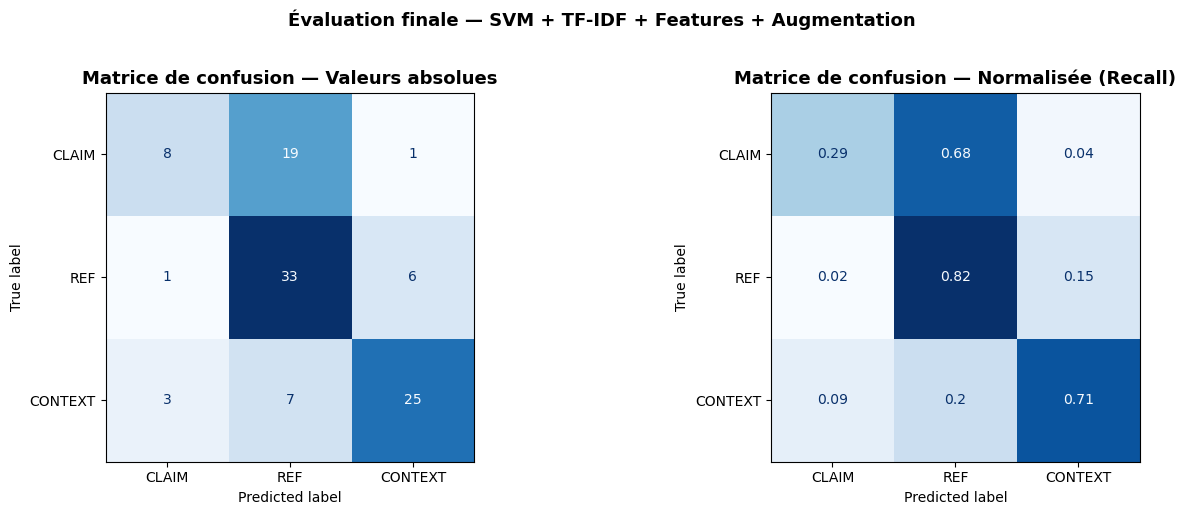

In [79]:
# === VISUALISATION 7 : MATRICE DE CONFUSION FINALE ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. MATRICE DE CONFUSION (VALEURS ABSOLUES) ────────────────────────────────

# Calcul de la matrice de comptage entre les labels réels et les prédictions.
# On spécifie l'ordre des labels pour assurer la cohérence de lecture sur les axes.
cm_final = confusion_matrix(y_test_f, y_pred_test,
                             labels=['CLAIM', 'REF', 'CONTEXT'])

# Affichage de la matrice brute sur le premier sous-graphique.
# Cette vue permet de visualiser le volume réel de tweets bien classés (diagonale)
# et d'identifier les volumes d'erreurs entre chaque paire de classes.
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final,
                               display_labels=['CLAIM', 'REF', 'CONTEXT'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice de confusion — Valeurs absolues',
                   fontsize=13, fontweight='bold')

# ── 2. MATRICE DE CONFUSION NORMALISÉE (RAPPEL / RECALL) ──────────────────────

# Calcul de la normalisation par ligne (axis=1).
# En divisant chaque cellule par la somme de sa ligne respective, on neutralise
# l'effet du déséquilibre des classes pour visualiser le taux de rappel (Recall).
# Chaque ligne somme alors à 1.0 (ou 100% des échantillons de la classe réelle).
cm_norm = cm_final.astype(float) / cm_final.sum(axis=1, keepdims=True)

# Affichage de la matrice normalisée (arrondie à deux décimales) sur le second graphique.
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2),
                                    display_labels=['CLAIM', 'REF', 'CONTEXT'])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matrice de confusion — Normalisée (Recall)',
                   fontsize=13, fontweight='bold')

# Configuration de la mise en page globale
plt.suptitle('Évaluation finale — SVM + TF-IDF + Features + Augmentation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [80]:
# === SAUVEGARDE ET PERSISTANCE DU MODÈLE FINAL ===

# ── 1. ENTRAÎNEMENT DE PRODUCTION ─────────────────────────────────────────────
# Le modèle est ré-entraîné sur l'intégralité du corpus d'entraînement augmenté.
# On utilise le pipeline intégrant SMOTE et le classifieur SVM avec les 
# hyperparamètres optimisés précédemment.
modele_final = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', SVC(
        C=study_svm.best_params['C'],
        kernel=study_svm.best_params['kernel'],
        gamma=study_svm.best_params.get('gamma', 'scale'),
        class_weight='balanced',
        random_state=42
    ))
])
modele_final.fit(X_train_f, y_train_f)

# ── 2. SÉRIALISATION DES COMPOSANTS (EXPORT) ──────────────────────────────────
# La sauvegarde séparée du modèle, du vectoriseur et des listes de features 
# est indispensable pour pouvoir reconstruire l'espace vectoriel lors de 
# l'inférence sur de nouveaux tweets.

joblib.dump(modele_final, 'modele_tache3_final.pkl')
joblib.dump(tfidf_v2, 'tfidf_tache3_final.pkl')
joblib.dump(struct_features_selected, 'struct_features_final.pkl')
joblib.dump(sci_features_selected,    'sci_features_final.pkl')

# ── 3. RÉCAPITULATIF DE LA SAUVEGARDE ─────────────────────────────────────────
print('Inventaire des fichiers de production générés :')
print(f'  - Modèle prédictif : modele_tache3_final.pkl')
print(f'  - Vectoriseur TF-IDF : tfidf_tache3_final.pkl')
print(f'  - Variables structurelles : struct_features_final.pkl')
print(f'  - Variables scientifiques : sci_features_final.pkl')

print(f'\nConfiguration finale sauvegardée :')
print(f'  - Régularisation (C) : {study_svm.best_params["C"]:.4f}')
print(f'  - Noyau (kernel) : {study_svm.best_params["kernel"]}')
print(f'  - Gamma : {study_svm.best_params.get("gamma", "scale")}')
print(f'  - Gestion du déséquilibre : class_weight=balanced')

Inventaire des fichiers de production générés :
  - Modèle prédictif : modele_tache3_final.pkl
  - Vectoriseur TF-IDF : tfidf_tache3_final.pkl
  - Variables structurelles : struct_features_final.pkl
  - Variables scientifiques : sci_features_final.pkl

Configuration finale sauvegardée :
  - Régularisation (C) : 0.0112
  - Noyau (kernel) : linear
  - Gamma : scale
  - Gestion du déséquilibre : class_weight=balanced


<a id='13'></a>
## 13. Tableau comparatif final

Synthèse de toutes les expériences menées pour répondre à la question 4 du sujet :  
*"Comparer empiriquement les différents choix et expliquer l'impact sur la classification."*

In [81]:
# === TABLEAU COMPARATIF ET BILAN DES EXPÉRIENCES ===

# Fonction utilitaire pour extraire les performances individuelles par catégorie
def f1_par_classe(y_true, y_pred):
    # Calcul du F1-score pour chaque label dans l'ordre : CLAIM, REF, CONTEXT
    f1 = f1_score(y_true, y_pred, average=None,
                  labels=['CLAIM', 'REF', 'CONTEXT'])
    return f1[0], f1[1], f1[2]

# Extraction des scores pour les trois jalons du projet
f1c_base, f1r_base, f1x_base = f1_par_classe(y_test,   y_pred_base)
f1c_svm,  f1r_svm,  f1x_svm  = f1_par_classe(y_test,   y_pred_svm)
f1c_aug,  f1r_aug,  f1x_aug  = f1_par_classe(y_test_f, y_pred_test)

# Construction de la structure de données pour le bilan comparatif
tableau = pd.DataFrame({
    'Expérience' : [
        '1. SVM baseline (C=1, rbf, balanced)',
        f'2. SVM optimisé Optuna (C={study_svm.best_params["C"]:.2f}, {study_svm.best_params["kernel"]})',
        '3. SVM Optuna + Augmentation CONTEXT',
    ],
    'F1 macro'  : [f1_base, f1_svm, f1_apres],
    'F1 CLAIM'  : [f1c_base, f1c_svm, f1c_aug],
    'F1 REF'    : [f1r_base, f1r_svm, f1r_aug],
    'F1 CONTEXT': [f1x_base, f1x_svm, f1x_aug],
    'Observation': [
        'Référence de base',
        f'Gain via optimisation : {f1_svm - f1_base:+.3f}',
        f'Impact augmentation : F1 CONTEXT {f1x_svm:.2f} → {f1x_aug:.2f}'
    ]
})

# Formatage des scores pour une lecture optimale
tableau_aff = tableau.copy()
for col in ['F1 macro', 'F1 CLAIM', 'F1 REF', 'F1 CONTEXT']:
    tableau_aff[col] = tableau_aff[col].round(3)

# Affichage du tableau de synthèse final
print('=' * 100)
print(tableau_aff.to_string(index=False))
print('=' * 100)

# Conclusion sur l'approche la plus performante
print(f'\nConfiguration optimale retenue : SVM Optuna + Augmentation CONTEXT')
print(f'Performance F1 macro finale    : {f1_apres:.3f}')
print(f'Progression globale            : {f1_apres - f1_base:+.3f} par rapport au modèle initial')

                             Expérience  F1 macro  F1 CLAIM  F1 REF  F1 CONTEXT                                  Observation
   1. SVM baseline (C=1, rbf, balanced)     0.516     0.450   0.723       0.375                            Référence de base
2. SVM optimisé Optuna (C=0.01, linear)     0.427     0.421   0.707       0.154               Gain via optimisation : -0.089
   3. SVM Optuna + Augmentation CONTEXT     0.604     0.400   0.667       0.746 Impact augmentation : F1 CONTEXT 0.15 → 0.75

Configuration optimale retenue : SVM Optuna + Augmentation CONTEXT
Performance F1 macro finale    : 0.604
Progression globale            : +0.088 par rapport au modèle initial


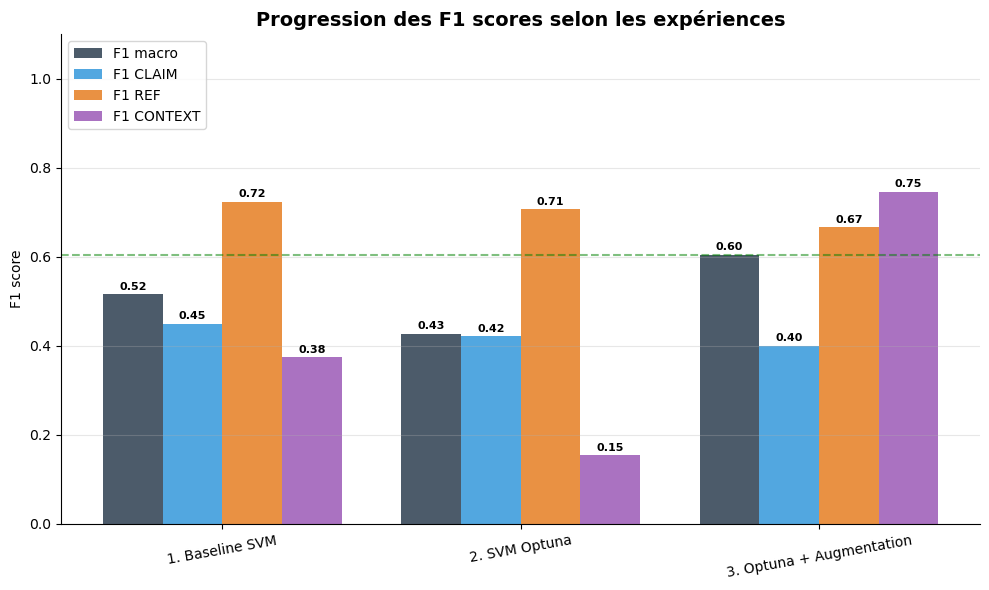

In [82]:
# === VISUALISATION 8 : Progression des F1 scores ===

fig, ax = plt.subplots(figsize=(10, 6))

x     = np.arange(len(tableau))
width = 0.20

bars1 = ax.bar(x - width*1.5, tableau['F1 macro'],   width,
               label='F1 macro',   color='#2C3E50', alpha=0.85)
bars2 = ax.bar(x - width*0.5, tableau['F1 CLAIM'],   width,
               label='F1 CLAIM',   color='#3498DB', alpha=0.85)
bars3 = ax.bar(x + width*0.5, tableau['F1 REF'],     width,
               label='F1 REF',     color='#E67E22', alpha=0.85)
bars4 = ax.bar(x + width*1.5, tableau['F1 CONTEXT'], width,
               label='F1 CONTEXT', color='#9B59B6', alpha=0.85)

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.2f}',
                ha='center', fontsize=8, fontweight='bold')

labels_exp = ['1. Baseline SVM', '2. SVM Optuna', '3. Optuna + Augmentation']
ax.set_xticks(x)
ax.set_xticklabels(labels_exp, rotation=10, fontsize=10)

ax.set_title('Progression des F1 scores selon les expériences',
             fontsize=14, fontweight='bold')
ax.set_ylabel('F1 score')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper left', fontsize=10)

ax.axhline(y=f1_apres, color='green', linestyle='--',
           alpha=0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()